In [75]:

from pathlib import Path
import numpy as np
from lightning import pytorch as pl
from lightning.pytorch.callbacks import ModelCheckpoint
from chemprop.featurizers.atom import MultiHotAtomFeaturizer
from rdkit.Chem.rdchem import HybridizationType
import pandas as pd
from rdkit import Chem
from chemprop import data, featurizers, models, nn
from ml_enhance import QuantumFPFileLoader
import pandas as pd
from chemprop.data import MoleculeDatapoint, MoleculeDataset
from chemprop.featurizers import SimpleMoleculeMolGraphFeaturizer

In [2]:
def preprocess_to_chemprop_format(
    raw_data: pd.DataFrame, featurizer: SimpleMoleculeMolGraphFeaturizer
) -> MoleculeDataset:
    all_data: list[MoleculeDatapoint] = [
        MoleculeDatapoint.from_smi(smi, [sol], keep_h=True)
        for _, (smi, sol) in raw_data[["smiles", "solubility"]].iterrows()
    ]

    return MoleculeDataset(all_data, featurizer)

In [241]:
df = pd.read_csv("../data/processed_dataset_wo_metals_w_even_more_qm2.csv")

featurizer = SimpleMoleculeMolGraphFeaturizer()
processed = preprocess_to_chemprop_format(df, featurizer)

In [242]:
df

,id,atomization_energy,homo_lumo_gap,ionization_energy,electron_affinity,chemical_potential,molecular_dipole_norm,molecular_quadrupole_principal_invariant_2,molecular_quadrupole_principal_invariant_3,molecular_polarizability_mean,...,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,canon_smiles,solubility
0,0.0,5.239994,0.089513,0.476438,0.201907,-0.338539,1.513984,-191.687655,-37.755113,-99.744189,...,0,0,0,0,0,0,0,0,O=C1Nc2cccc3cccc1c23,-3.254767
1,1.0,3.330826,0.105979,0.507545,0.200001,-0.356143,0.965182,-188.636399,720.869344,-95.248037,...,0,0,0,0,0,0,0,0,O=Cc1ccc(Cl)cc1,-2.177078
2,10.0,7.140100,0.154440,0.463887,0.109782,-0.296101,0.909688,-169.958738,291.625442,-98.287723,...,0,0,0,0,0,0,0,0,CC(C)(C)c1ccc(OCC2CO2)cc1,-3.430239
3,100.0,5.850939,0.073945,0.299042,0.004866,-0.145684,5.103982,-1306.769545,16565.487506,-90.301117,...,0,0,0,0,0,0,0,0,Cc1cccc(C)c1OCC(=O)O,-2.256645
4,1000.0,8.519924,0.068689,0.479849,0.249515,-0.373551,2.145071,-670.362641,-1839.250752,-230.053983,...,0,0,0,0,0,0,0,0,COC(=O)c1ccc(C(=O)Nc2cc(Cl)ccc2Cl)cc1[N+](=O)[O-],-5.965155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,995.0,11.372887,0.138098,0.408731,0.124741,-0.268097,0.635633,-223.220583,-1246.983393,-175.035008,...,0,0,0,0,0,0,0,0,CCc1cc(Cc2cc(CC)c(N)c(CC)c2)cc(CC)c1N,-5.848588
8759,996.0,13.614082,0.089834,0.440186,0.213271,-0.327415,1.863283,-1226.796840,8353.551561,-210.040379,...,0,0,0,0,0,0,0,0,C=CC(=O)OCCOc1ccc(C(C)(C)c2ccc(OCCOC(=O)C=C)cc...,-5.999482
8760,997.0,13.105128,0.122062,0.417600,0.165875,-0.283515,0.372170,-41.189025,8.506481,-244.342833,...,0,0,0,0,0,0,0,0,CC(c1ccccc1)c1ccc(Nc2ccc(C(C)c3ccccc3)cc2)cc1,-5.964169
8761,998.0,8.336346,0.137505,0.478987,0.167822,-0.337834,0.956828,-116.853092,-243.342458,-112.376440,...,0,0,0,0,0,0,1,0,CCCCC(CC)COC(=O)c1ccccc1,-5.767785


In [41]:
df.filter(regex="atomic")

,avg_atomic_sasa,avg_atomic_quadrupole_principal_invariant_3,avg_atomic_fukui_plus,avg_atomic_dipole_norm,avg_atomic_polarizability_anisotropy,avg_atomic_fukui_minus,avg_atomic_polarizability_mean,avg_atomic_quadrupole_principal_invariant_2,avg_atomic_dipole_dipole_interaction,avg_atomic_charge_quadrupole_interaction,avg_atomic_charge_dipole_interaction
0,34.943194,-0.013586,-0.050000,0.091638,4.352230,-0.050000,-0.252804,-0.093362,0.000243,-0.000061,0.000195
1,43.677327,-0.017203,-0.071429,0.105602,17.344523,-0.071429,-2.399558,-0.123951,0.000551,-0.000249,-0.000051
2,29.060005,-0.003608,-0.030303,0.132485,2.318236,-0.030303,0.099307,-0.050832,0.000705,-0.000237,-0.000004
3,32.892185,-0.005130,-0.041667,0.123096,3.119734,-0.041667,-0.024867,-0.057646,0.000501,0.000112,0.000167
4,38.042433,-0.009921,-0.029412,0.136925,16.157665,-0.029412,-1.863443,-0.096304,0.000392,-0.000060,0.000170
...,...,...,...,...,...,...,...,...,...,...,...
8832,26.694620,-0.002712,-0.018868,0.110348,2.790758,-0.018868,0.145415,-0.038458,0.000225,-0.000084,0.000104
8833,30.179130,-0.008329,-0.016949,0.136620,3.442060,-0.016949,0.039582,-0.077869,0.000260,-0.000086,0.000018
8834,28.627679,-0.010447,-0.017857,0.090201,4.609526,-0.017857,0.024242,-0.077544,0.000117,-0.000030,0.000055
8835,28.648928,-0.005793,-0.025641,0.119540,2.040436,-0.025641,0.085753,-0.051035,0.000427,-0.000108,0.000062


In [5]:
loader = QuantumFPFileLoader("../data/QuantumFP/QFP_output")
filelist = loader.list_output_files()

In [58]:
atomic_features = [
    "atomic_fukui_minus",
    "atomic_fukui_plus",
    "atomic_dipole_norm",
    "atomic_quadrupole_principal_invariant_2",
    "atomic_quadrupole_principal_invariant_3",
    "atomic_polarizability_mean",
    "atomic_polarizability_anisotropy",
    "atomic_sasa",
    "partial_charge",
]


In [257]:
from scipy.constants import (
    Avogadro,  # 1/mol
    Boltzmann,  # in J/K
)

def aggregate_atom_features(df: pd.DataFrame, object_cols: list[str]) -> pd.DataFrame:
    k_B: float = Boltzmann * Avogadro * 0.000239005736
    
    # boltzmann weights
    G = df["gibbs_free_energy_300K"].unique()
    delta_G = G - G.min()
    boltzmann_factors = np.exp(-delta_G / (k_B * 300))
    weights = boltzmann_factors / boltzmann_factors.sum()

    # extract atom indices and values in one shot
    arr = np.array(df[object_cols].values.tolist())
    # shape: (n_conformers * n_atoms, n_features, 2)

    atom_idx = arr[:, 0, 0].astype(int)  # from first feature column
    values = arr[:, :, 1].astype(float)  # shape: (n_conformers * n_atoms, n_features)

    # derive shapes from data
    n_conformers = len(weights)
    n_atoms = len(np.unique(atom_idx))
    n_features = len(object_cols)

    print(n_conformers, n_atoms, n_features)

    # vectorized boltzmann average
    atom_matrix = values.reshape(n_conformers, n_atoms, n_features)
    averages = np.einsum("i,ijk->jk", weights, atom_matrix)

    result = pd.DataFrame(averages, columns=object_cols)
    result.insert(0, "atom", np.unique(atom_idx))
    result.insert(0, "original_smiles", df["original_smiles"].iloc[0])
    
    return result

In [261]:
for file in filelist[:3]:
    for sdf in loader.stream_conformer_dataframe(file):
        # target extraction
        sdf["gibbs_free_energy_300K"] = sdf["gibbs_free_energy"].map(lambda x: x[1][1])

        # select relevant columns
        tdf_atomic = sdf[["original_smiles", "gibbs_free_energy_300K"] + atomic_features]
        object_cols = tdf_atomic.select_dtypes(include="object").columns.tolist()

        # explode all atomic feature columns at once
        exploded_df = tdf_atomic.explode(object_cols)

        result = aggregate_atom_features(exploded_df, object_cols)
    
result

1 20 9
1 14 9
19 33 9


,original_smiles,atom,atomic_fukui_minus,atomic_fukui_plus,atomic_dipole_norm,atomic_quadrupole_principal_invariant_2,atomic_quadrupole_principal_invariant_3,atomic_polarizability_mean,atomic_polarizability_anisotropy,atomic_sasa,partial_charge
0,[C:1]([C:2]([C:3]([H:19])([H:20])[H:21])([C:4]...,1,0.017851,0.013709,0.098735,-0.036257,-0.002588,1.064591,0.643913,48.941324,0.107596
1,[C:1]([C:2]([C:3]([H:19])([H:20])[H:21])([C:4]...,2,-0.001922,-0.014315,0.018827,-0.001733,0.000003,1.528534,2.134431,0.254262,-0.026053
2,[C:1]([C:2]([C:3]([H:19])([H:20])[H:21])([C:4]...,3,0.015921,0.007061,0.098631,-0.037996,-0.002786,1.066760,0.712668,51.929929,0.106678
3,[C:1]([C:2]([C:3]([H:19])([H:20])[H:21])([C:4]...,4,0.016492,0.009013,0.098629,-0.037468,-0.002726,1.065766,0.692398,51.216297,0.106908
4,[C:1]([C:2]([C:3]([H:19])([H:20])[H:21])([C:4]...,5,-0.062572,-0.054922,0.079925,-0.143164,-0.013516,0.208325,13.153487,13.286472,0.000871
5,[C:1]([C:2]([C:3]([H:19])([H:20])[H:21])([C:4]...,6,-0.060017,-0.022988,0.018346,-0.187181,-0.030279,0.032469,6.673723,39.699135,0.037484
6,[C:1]([C:2]([C:3]([H:19])([H:20])[H:21])([C:4]...,7,-0.056696,-0.026961,0.039167,-0.148526,-0.021314,-0.098763,6.802420,47.026187,0.062897
7,[C:1]([C:2]([C:3]([H:19])([H:20])[H:21])([C:4]...,8,-0.058433,-0.038695,0.273881,-0.153835,0.020152,0.325166,10.942337,24.771491,-0.139111
8,[C:1]([C:2]([C:3]([H:19])([H:20])[H:21])([C:4]...,9,-0.050387,-0.099409,0.254811,-0.015912,-0.000297,-0.094031,0.666089,33.641916,0.278114
9,[C:1]([C:2]([C:3]([H:19])([H:20])[H:21])([C:4]...,10,0.014065,0.017853,0.214310,-0.154923,-0.005889,1.322675,2.903281,30.339503,-0.077219


In [ ]:
split = pd.read_pickle("hpc_splits.pkl")[0][1]
len([processed[i] for i in split])

1753

In [8]:
from torch.utils.data import Subset
ds = Subset(processed, split)

data.build_dataloader(ds, batch_size=10, persistent_workers=True)

ValueError: persistent_workers option needs num_workers > 0

In [9]:
split

array([   5,    9,   11, ..., 8741, 8758, 8760], shape=(1753,))

In [10]:
from sklearn.model_selection import KFold

inner_cv = KFold(5, shuffle=True, random_state=99)
list(inner_cv.split(split))[0][1]

array([   2,    3,    6,    9,   14,   15,   16,   18,   22,   25,   28,
         30,   32,   42,   43,   44,   57,   62,   63,   74,   81,   86,
        107,  111,  112,  119,  126,  131,  136,  137,  141,  143,  152,
        156,  158,  160,  163,  167,  168,  172,  174,  182,  191,  201,
        202,  203,  207,  211,  217,  222,  224,  231,  233,  234,  253,
        259,  261,  266,  271,  273,  282,  285,  292,  304,  307,  310,
        313,  317,  333,  336,  342,  350,  351,  356,  360,  376,  382,
        383,  385,  389,  390,  391,  392,  396,  405,  407,  411,  412,
        416,  418,  442,  456,  461,  464,  468,  478,  481,  482,  487,
        491,  500,  504,  509,  519,  522,  523,  524,  538,  541,  547,
        548,  561,  562,  564,  565,  569,  576,  581,  583,  587,  594,
        596,  597,  600,  615,  616,  628,  636,  644,  645,  648,  649,
        654,  655,  664,  666,  671,  679,  680,  685,  686,  693,  700,
        704,  718,  719,  721,  722,  730,  738,  7

In [11]:
loader = QuantumFPFileLoader("data/QuantumFP/QFP_output")
filelist = loader.list_output_files()
for df in loader.stream_conformer_dataframe(filelist[0]):
    tdf = df

In [12]:
tdf["original_smiles"].values

<StringArray>
['[O:1]=[C:2]1[N:3]([H:14])[c:4]2[c:5]([H:15])[c:6]([H:16])[c:7]([H:17])[c:8]3[c:9]([H:18])[c:10]([H:19])[c:11]([H:20])[c:12]1[c:13]23']
Length: 1, dtype: string

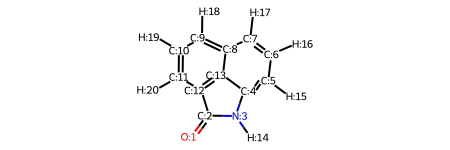

In [13]:
Chem.MolFromSmiles('[O:1]=[C:2]1[N:3]([H:14])[c:4]2[c:5]([H:15])[c:6]([H:16])[c:7]([H:17])[c:8]3[c:9]([H:18])[c:10]([H:19])[c:11]([H:20])[c:12]1[c:13]23', sanitize=False)

In [14]:
for atom in Chem.MolFromSmiles('[O:1]=[C:2]1[N:3]([H:14])[c:4]2[c:5]([H:15])[c:6]([H:16])[c:7]([H:17])[c:8]3[c:9]([H:18])[c:10]([H:19])[c:11]([H:20])[c:12]1[c:13]23', sanitize=False).GetAtoms():
    print(atom.GetAtomMapNum())

1
2
3
14
4
5
15
6
16
7
17
8
9
18
10
19
11
20
12
13


In [15]:
import numpy as np

dips = [dip[1] for dip in tdf["atomic_dipole"][0]]
np.array(dips).sum(axis=0)

array([-9.72435218e-02, -1.85325173e-01,  8.11703750e-07])

In [16]:
tdf["molecular_dipole"][0]

[-1.5076436182670554, -0.13841485683182708, 1.1795803790465398e-06]

In [17]:
tdf["atomic_charge_dipole_interaction"].to_numpy()

array([list([[1, 2, 0.0033359316094680835], [1, 3, -0.00022245634665863908], [1, 4, -0.005489815938149715], [1, 5, 8.532834909950155e-05], [1, 6, -0.00046551375264068694], [1, 7, -0.0003613352452160964], [1, 8, 0.00017165466008306333], [1, 9, -0.0002038406978157412], [1, 10, -0.0007695176822570202], [1, 11, 0.0008947084902147923], [1, 12, -0.004802244330944193], [1, 13, -0.00029005914614982473], [1, 14, 0.004214639729920416], [1, 15, 0.001189323609975297], [1, 16, 0.0011940645064860552], [1, 17, 0.0012293819223028993], [1, 18, 0.0014993020387240703], [1, 19, 0.0015671014044818313], [1, 20, 0.0007703595383967832], [2, 1, 0.03578395325359559], [2, 3, 0.0021648156401432184], [2, 4, 0.007935216890220349], [2, 5, -6.56953249425921e-05], [2, 6, 0.000490255693567733], [2, 7, 0.00038585728343693183], [2, 8, -0.00021292260398937486], [2, 9, 0.0002724631673193278], [2, 10, 0.0007386117298645389], [2, 11, -0.0008021877051539738], [2, 12, 0.009777806550568919], [2, 13, 0.0005466456771364342], [2, 

In [18]:
all_data[0].mol

NameError: name 'all_data' is not defined

In [19]:
for atom in all_data[0].mol.GetAtoms():
    print(atom.GetAtomMapNum())

NameError: name 'all_data' is not defined

In [20]:
atomic_nums = list(range(1, 37)) + [53] # Look up which atomic numbers occur in the dataset
degrees = [0, 1, 2, 3, 4, 5]
formal_charges = []
chiral_tags = [0, 1, 2, 3]
num_Hs = [0, 1, 2, 3, 4]
hybridizations = [HybridizationType.S, HybridizationType.SP, HybridizationType.SP2, HybridizationType.SP2D, HybridizationType.SP3, HybridizationType.SP3D, HybridizationType.SP3D2]
featurizer = MultiHotAtomFeaturizer(
    atomic_nums, degrees, formal_charges, chiral_tags, num_Hs, hybridizations
)
featurizer(atom_to_featurize)

NameError: name 'atom_to_featurize' is not defined

In [21]:
df = pd.read_csv(r"data\processed_dataset.csv")[:1000]

In [22]:
from chemprop.models import MPNN
from chemprop.nn import BondMessagePassing, Aggregation, RegressionFFN
# from chemprop.nn.metrics import MSEMetric

In [23]:
def build_model():
    mp = BondMessagePassing(
        d_h=300,
        depth=3
    )

    agg = Aggregation(
        method="mean" # should be norm or something else as solubility is extensive (dependent on size)
    )

    ffn = RegressionFFN(
        input_dim=300,
        hidden_dim=300,
        n_layers=1,
        output_dim=1,
        dropout=0.1
    )

    return MPNN(mp, agg, ffn)

In [24]:
all_data = [data.MoleculeDatapoint.from_smi(smi, [sol], keep_h=True) for _, (smi, sol) in df[["smiles", "solubility"]].iterrows()]

In [25]:
mols = [d.mol for d in all_data]  # RDkit Mol objects are use for structure based splits

train_indices, val_indices, test_indices = data.make_split_indices(mols, "random", (0.8, 0.1, 0.1))  # unpack the tuple into three separate lists
train_indices

The return type of make_split_indices has changed in v2.1 - see help(make_split_indices)


[[np.int64(859),
  np.int64(298),
  np.int64(553),
  np.int64(672),
  np.int64(971),
  np.int64(27),
  np.int64(231),
  np.int64(306),
  np.int64(706),
  np.int64(496),
  np.int64(558),
  np.int64(784),
  np.int64(239),
  np.int64(578),
  np.int64(55),
  np.int64(906),
  np.int64(175),
  np.int64(14),
  np.int64(77),
  np.int64(31),
  np.int64(481),
  np.int64(310),
  np.int64(311),
  np.int64(883),
  np.int64(788),
  np.int64(45),
  np.int64(103),
  np.int64(760),
  np.int64(1),
  np.int64(823),
  np.int64(710),
  np.int64(614),
  np.int64(790),
  np.int64(408),
  np.int64(736),
  np.int64(957),
  np.int64(366),
  np.int64(918),
  np.int64(267),
  np.int64(230),
  np.int64(996),
  np.int64(635),
  np.int64(698),
  np.int64(251),
  np.int64(783),
  np.int64(819),
  np.int64(141),
  np.int64(316),
  np.int64(587),
  np.int64(331),
  np.int64(295),
  np.int64(262),
  np.int64(432),
  np.int64(862),
  np.int64(582),
  np.int64(272),
  np.int64(270),
  np.int64(987),
  np.int64(319),
  np.

In [26]:
featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()

In [ ]:
splits = pd.read_pickle("hpc_splits.pkl")
for idx, split in enumerate(splits):
    print(idx)
    train_idxs, test_idxs = split
    train_idxs = train_idxs.reshape(1, -1)
    test_idxs = test_idxs.reshape(1, -1)

    train_data, _, test_data = data.split_data_by_indices(
        data=all_data, train_indices=train_idxs, test_indices=test_indices
    )

    print(type(train_data[0][0]))
    print(np.array(train_data[0])[[1, 2, 3]])

    test_dset = data.MoleculeDataset(test_data[0], featurizer)

    best_params = run_tuning_per_fold(...)


    train_dset = data.MoleculeDataset(train_data[0], featurizer)
    scaler = train_dset.normalize_targets()


    break

0


IndexError: list index out of range

In [27]:
train_data, val_data, test_data = data.split_data_by_indices(
    all_data, train_indices, val_indices, test_indices
)

In [28]:


train_dset = data.MoleculeDataset(train_data[0], featurizer)
scaler = train_dset.normalize_targets()

# train_dset._X_d


val_dset = data.MoleculeDataset(val_data[0], featurizer)
val_dset.normalize_targets(scaler)

test_dset = data.MoleculeDataset(test_data[0], featurizer)

In [29]:
num_workers = 1
train_loader = data.build_dataloader(train_dset, num_workers=num_workers)
val_loader = data.build_dataloader(val_dset, num_workers=num_workers, shuffle=False)
test_loader = data.build_dataloader(test_dset, num_workers=num_workers, shuffle=False)

In [30]:
len(val_loader)

2

In [31]:
mp = nn.BondMessagePassing()
agg = nn.MeanAggregation()
ffn = nn.RegressionFFN()

batch_norm = True
metric_list = [nn.metrics.MSE(), nn.metrics.R2Score()]

mpnn = models.MPNN(mp, agg, ffn, batch_norm=True, metrics=metric_list)
mpnn

MPNN(
  (message_passing): BondMessagePassing(
    (W_i): Linear(in_features=86, out_features=300, bias=False)
    (W_h): Linear(in_features=300, out_features=300, bias=False)
    (W_o): Linear(in_features=372, out_features=300, bias=True)
    (dropout): Dropout(p=0.0, inplace=False)
    (tau): ReLU()
    (V_d_transform): Identity()
    (graph_transform): Identity()
  )
  (agg): MeanAggregation()
  (bn): BatchNorm1d(300, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (predictor): RegressionFFN(
    (ffn): MLP(
      (0): Sequential(
        (0): Linear(in_features=300, out_features=300, bias=True)
      )
      (1): Sequential(
        (0): ReLU()
        (1): Dropout(p=0.0, inplace=False)
        (2): Linear(in_features=300, out_features=1, bias=True)
      )
    )
    (criterion): MSE(task_weights=[[1.0]])
    (output_transform): Identity()
  )
  (X_d_transform): Identity()
  (metrics): ModuleList(
    (0): MSE(task_weights=[[1.0]])
    (1): R2Score()
    (2): MSE(

In [32]:
class DebugCallback(pl.Callback):
    def on_validation_epoch_end(self, trainer, pl_module):
        print("Callback metrics:", trainer.callback_metrics)

In [33]:
# Configure model checkpointing
checkpointing = ModelCheckpoint(
    "checkpoints",  # Directory where model checkpoints will be saved
    "best-{epoch}-{val_loss:.2f}",  # Filename format for checkpoints, including epoch and validation loss
    "val_loss",  # Metric used to select the best checkpoint (based on validation loss)
    mode="min",  # Save the checkpoint with the lowest validation loss (minimization objective)
    save_last=True,  # Always save the most recent checkpoint, even if it's not the best
)


trainer = pl.Trainer(
    logger=False,
    enable_checkpointing=False, # Use `True` if you want to save model checkpoints. The checkpoints will be saved in the `checkpoints` folder.
    enable_progress_bar=True,
    accelerator="auto",
    devices=1,
    max_epochs=5, # number of epochs to train for
    callbacks=[DebugCallback()], # Use the configured checkpoint callback
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [34]:
trainer.callback_metrics

{}

In [35]:
trainer.fit(mpnn, train_loader, val_loader)

Loading `train_dataloader` to estimate number of stepping batches.
c:\Users\thibo\OneDrive\Bureaublad\Enhancing-aqueous-solubility-prediction-models\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\thibo\OneDrive\Bureaublad\Enhancing-aqueous-solubility-prediction-models\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  227 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    600 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 90.6 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 318 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 318 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

c:\Users\thibo\OneDrive\Bureaublad\Enhancing-aqueous-solubility-prediction-models\.venv\Lib\site-packages\lightning
\pytorch\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'val_dataloader' 
to speed up the dataloader worker initialization.

...

Callback metrics: {'train_loss': tensor(0.3283), 'train_loss_step': tensor(0.3283), 'val/mse': tensor(0.8403), 
'val/r2': tensor(0.1694), 'val_loss': tensor(0.8403), 'train_loss_epoch': tensor(0.6192)}

Callback metrics: {'train_loss': tensor(0.4800), 'train_loss_step': tensor(0.4800), 'val/mse': tensor(0.6862), 
'val/r2': tensor(0.3218), 'val_loss': tensor(0.6862), 'train_loss_epoch': tensor(0.3505)}

Callback metrics: {'train_loss': tensor(0.3218), 'train_loss_step': tensor(0.3218), 'val/mse': tensor(0.6739), 
'val/r2': tensor(0.3339), 'val_loss': tensor(0.6739), 'train_loss_epoch': tensor(0.2974)}

Callback metrics: {'train_loss': tensor(0.0966), 'train_loss_step': tensor(0.0966), 'val/mse': tensor(0.4720), 
'val/r2': tensor(0.5335), 'val_loss': tensor(0.4720), 'train_loss_epoch': tensor(0.2736)}

`Trainer.fit` stopped: `max_epochs=5` reached.


In [36]:
trainer.callback_metrics

{'train_loss': tensor(0.2262),
 'train_loss_step': tensor(0.0966),
 'val/mse': tensor(0.4720),
 'val/r2': tensor(0.5335),
 'val_loss': tensor(0.4720),
 'train_loss_epoch': tensor(0.2262)}

In [141]:
test = trainer.test(mpnn, val_loader, weights_only=False)

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          test/r2          │    0.5721385478973389     │
│         test/rmse         │    0.6579418778419495     │
└───────────────────────────┴───────────────────────────┘

In [142]:
test[0]

{'test/rmse': 0.6579418778419495, 'test/r2': 0.5721385478973389}

In [146]:
from dataclasses import dataclass, field, asdict
import torch

@dataclass
class FixedParams:
    use_gpu: bool = torch.cuda.is_available()
    batch_size: int = 100
    num_workers: int = 1
    dropout: float = 0.1
    n_epochs: int = 30
    metrics: list = field(default_factory=lambda: [nn.metrics.MSE(), nn.metrics.R2Score()])
    opt_n_trials: int = 30
    opt_direction: str = "minimize"

asdict(FixedParams())

{'use_gpu': False,
 'batch_size': 100,
 'num_workers': 1,
 'dropout': 0.1,
 'n_epochs': 30,
 'metrics': [MSE(task_weights=[[1.0]]), R2Score()],
 'opt_n_trials': 30,
 'opt_direction': 'minimize'}

In [150]:
import pickle

dataset = pd.read_pickle("data/chemprop_dataset1.pkl")

dataset[0].mg

MolGraph(V=array([[0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.15999],
       [0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.12011],
       [0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.14007],
       ...,
       [1.     , 0.     , 0.     , ..., 0.     , 0.     , 0.01008],
       [0.     , 0.     , 0.     , ..., 0.     , 1.     , 0.12011],
       [0.     , 0.     , 0.     , ..., 0.     , 1.     , 0.12011]],
      shape=(20, 72), dtype=float32), E=array([[0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
       [